# Plot the E-field in the cavity wrt the length of the pin and the mode

## Functions

In [6]:
import os
import re
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
 

In [13]:
dir_images = Path("Data/Pictures_Eigenmodes_Pin/")
mm_values = np.arange(65, 100, 5)
mode_values = np.arange(1, 4)
pattern = re.compile(r"20260507_Oyz_(\d+)mm_mode(\d+)",re.IGNORECASE)

In [9]:
def find_images(directory):
    images = {}
    extensions = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif", ".webp"}
    for f in directory.iterdir():
        if f.suffix.lower() not in extensions:
            continue
        m = pattern.search(f.stem)
        if m:
            mm, mode = int(m.group(1)), int(m.group(2))
            images[(mm, mode)] = f
        
    return images

In [17]:
def build_figure(images):
    n_cols = len(mm_values)
    n_rows = len(mode_values)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), squeeze=False)
    
    fig.suptitle("Eigenmodes", fontsize=14, fontweight="bold", y=1)

    for row_idx, mode in enumerate(mode_values):
        for col_idx, mm in enumerate(mm_values):
            ax = axes[row_idx][col_idx]
            ax.set_xticks([])
            ax.set_yticks([])
 
            path = images.get((mm, mode))
            if path:
                img = mpimg.imread(str(path))
                ax.imshow(img)
                ax.set_title(f"{mm} mm | mode {mode}", fontsize=7, pad=3)
            else:
                # Cellule vide : affiche un carré gris avec un label
                ax.set_facecolor("#dddddd")
                ax.text(
                    0.5, 0.5,
                    f"{mm} mm\nmode {mode}\n(absent)",
                    ha="center", va="center",
                    fontsize=8, color="#888888",
                    transform=ax.transAxes
                )
 
            # Étiquettes de bord gauche (axe Y = mode)
            if col_idx == 0:
                ax.set_ylabel(f"Mode {mode}", fontsize=9, labelpad=6)
 
            # Étiquettes de bord haut (axe X = mm)
            if row_idx == 0:
                ax.set_xlabel(f"{mm} mm", fontsize=9, labelpad=4)
                ax.xaxis.set_label_position("top")
 
    # Titres globaux des axes
    fig.text(0.5, 1.03, "mm", ha="center", va="bottom", fontsize=11, fontweight="bold")
    fig.text(-0.01, 0.5, "Mode", ha="right", va="center",
             fontsize=11, fontweight="bold", rotation="vertical")
 
    plt.tight_layout()
    return fig

In [23]:
def main():
    # Permet de passer le dossier en argument : python afficher_captures.py /chemin/vers/dossier
    directory = dir_images
 
    if not directory.is_dir():
        print(f"Erreur : le dossier '{directory}' est introuvable.")
        sys.exit(1)
 
    images = find_images(directory)
 
    if not images:
        print(f"Aucune image correspondant au pattern trouvée dans '{directory}'.")
        sys.exit(1)
 
    fig = build_figure(images)
 
    plt.show()
 

## Plots

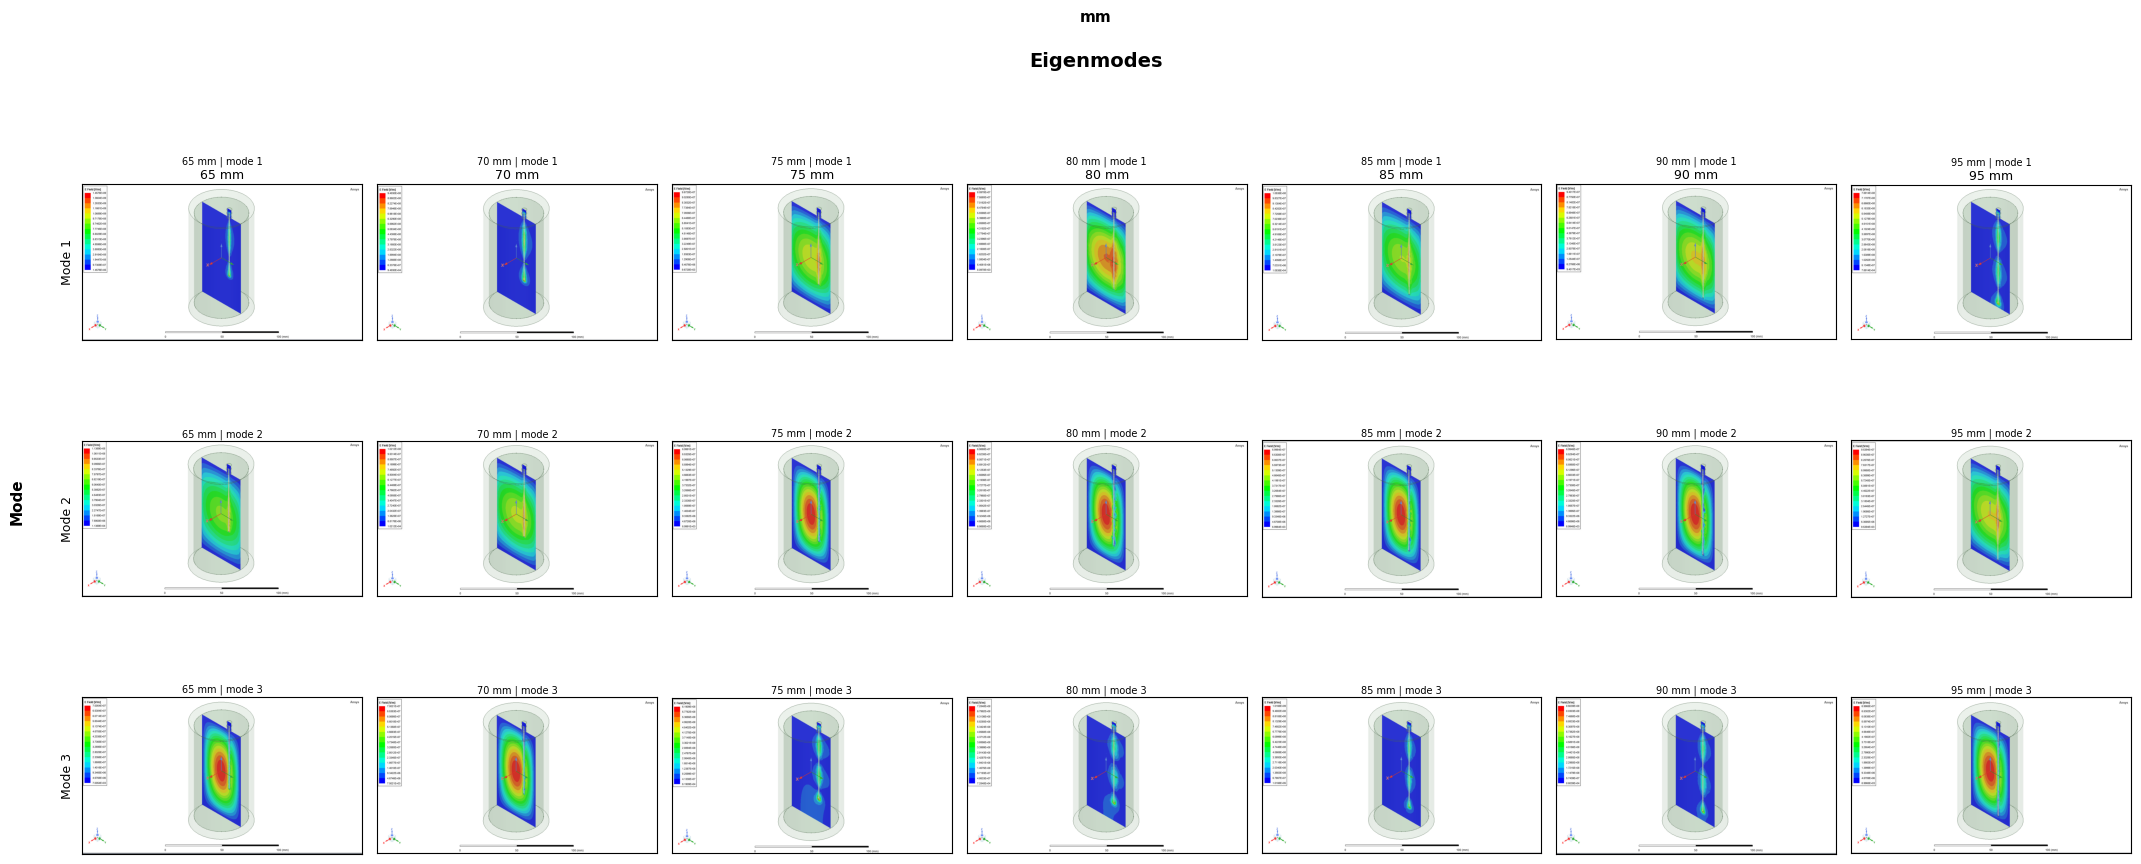

In [24]:
main()

Cavity length = 100mm | Cavity Radius = 25mm | Pin Radius = 0.5mm